# Feature Engineering, Cross-Validation & Model Comparison
**Dataset:** UCI Adult (Census Income) — same dataset and hold-out test split as Day 1/2
**Date:** 2 Sept 2026

This notebook covers: engineered features with justification → leak-safe pipeline integration → 5-fold cross-validated comparison of 3 models → paired statistical test + feature importance → feature selection check.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import make_scorer, precision_score, roc_auc_score, f1_score
from scipy import stats

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_STATE)

## Setup — Reload Data & Reproduce Day 1/2's Hold-Out Split

Same load + same stratified 70/10/20 split (`random_state=42`) as Day 1 and Day 2, so all comparisons across days stay apples-to-apples. Today's cross-validation work happens on the **training set** — the hold-out test set stays untouched.

In [2]:
COLS = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]

df = pd.read_csv("adult-all.csv", header=None, names=COLS, na_values="?", skipinitialspace=True)
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

X = df.drop(columns=["target","income"])
y = df["target"]

X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainfull, y_trainfull, test_size=0.125, stratify=y_trainfull, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")

train: (34188, 14), dev: (4885, 14), test: (9769, 14)


## Task 1 — Create & Justify Engineered Features

We propose **7 engineered features** (one more than the required minimum of 6). For each, we give a one-line justification and a quick univariate predictive signal, measured on the **training set only** (never dev/test, to avoid any peeking).

| # | Feature | Type | Creation rule | Justification |
|---|---|---|---|---|
| 1 | `age_bucket` | categorical | pd.cut into 5 age bands | Income vs. age is nonlinear (rises then plateaus/declines) — a linear model can't see that shape from raw age alone |
| 2 | `hours_bin` | categorical | pd.cut into part-time/full-time/overtime bands | Day 1 EDA showed a sharp income jump around the 40hr/week full-time threshold — bucketing captures that step |
| 3 | `has_capital_gain` | boolean | `capital-gain > 0` | Day 1 found capital-gain is ~zero-inflated; a simple "has any" flag may be more useful to a linear model than the raw skewed value |
| 4 | `log_capital_gain` | numeric | `log1p(capital-gain)` | Compresses the extreme right skew Day 1 flagged, so large values don't dominate distance/gradient-based models |
| 5 | `higher_ed` | boolean | `education-num >= 13` | This is literally Day 1's rule baseline — turning it into an explicit feature lets us check if the models "rediscover" it as important |
| 6 | `edu_hours_interaction` | numeric | `education-num * hours-per-week` | Captures the idea that education pays off *more* when combined with more hours worked — a linear model can't see this multiplicative effect from the two features separately |
| 7 | `is_married` | boolean | `marital-status` starts with `"Married"` | Day 1/2 both found marital-status among the strongest signals; collapsing 7 categories into one clean boolean gives a simpler, high-signal feature alongside the full one-hot encoding |

We compute a univariate signal for each: **mutual information** for all of them (works for both numeric and categorical/boolean), so they're directly comparable on one scale.

In [3]:
def build_engineered_features(X):
    '''Pure, leak-safe feature engineering: uses only values already present in each row.
    No fitting/statistics computed from the dataset (e.g. no group means) -- safe to apply
    identically to train, dev, and test without any risk of leakage.'''
    X = X.copy()
    X["age_bucket"] = pd.cut(
        X["age"], bins=[0, 25, 35, 45, 60, 100],
        labels=["<=25", "26-35", "36-45", "46-60", "60+"]
    ).astype(str)
    X["hours_bin"] = pd.cut(
        X["hours-per-week"], bins=[0, 20, 39, 40, 60, 200],
        labels=["part-time(<20)", "reduced(20-39)", "full-time(40)", "overtime(41-60)", "heavy(60+)"]
    ).astype(str)
    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)
    X["log_capital_gain"] = np.log1p(X["capital-gain"])
    X["higher_ed"] = (X["education-num"] >= 13).astype(int)
    X["edu_hours_interaction"] = X["education-num"] * X["hours-per-week"]
    X["is_married"] = X["marital-status"].str.startswith("Married").astype(int)
    return X

X_train_fe = build_engineered_features(X_train)
X_train_fe[["age_bucket","hours_bin","has_capital_gain","log_capital_gain",
            "higher_ed","edu_hours_interaction","is_married"]].head()

,age_bucket,hours_bin,has_capital_gain,log_capital_gain,higher_ed,edu_hours_interaction,is_married
44400,26-35,heavy(60+),1,9.617471,1,845,1
42131,36-45,reduced(20-39),0,0.000000,0,396,1
13335,36-45,full-time(40),1,8.552367,0,280,1
382,<=25,full-time(40),0,0.000000,0,400,1
46189,46-60,reduced(20-39),0,0.000000,0,360,0


In [4]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

engineered_cols = ["age_bucket","hours_bin","has_capital_gain","log_capital_gain",
                    "higher_ed","edu_hours_interaction","is_married"]
is_categorical_engineered = {"age_bucket": True, "hours_bin": True, "has_capital_gain": False,
                              "log_capital_gain": False, "higher_ed": False,
                              "edu_hours_interaction": False, "is_married": False}

signal_rows = []
for col in engineered_cols:
    vals = X_train_fe[col]
    if is_categorical_engineered[col]:
        vals_enc = LabelEncoder().fit_transform(vals.astype(str))
        mi = mutual_info_classif(vals_enc.reshape(-1,1), y_train, discrete_features=True, random_state=RANDOM_STATE)[0]
    else:
        mi = mutual_info_classif(vals.values.reshape(-1,1), y_train, discrete_features=False, random_state=RANDOM_STATE)[0]
    signal_rows.append({"feature": col, "type": "categorical" if is_categorical_engineered[col] else "numeric/boolean",
                         "mutual_info": round(mi, 4)})

feature_dictionary = pd.DataFrame(signal_rows).sort_values("mutual_info", ascending=False)
feature_dictionary

,feature,type,mutual_info
6,is_married,numeric/boolean,0.1068
5,edu_hours_interaction,numeric/boolean,0.0835
3,log_capital_gain,numeric/boolean,0.0805
0,age_bucket,categorical,0.0603
4,higher_ed,numeric/boolean,0.0470
1,hours_bin,categorical,0.0376
2,has_capital_gain,numeric/boolean,0.0281


**Reading the signal table:** features tied to marital status / education / capital-gain (`is_married`, `higher_ed`, `has_capital_gain`, `log_capital_gain`, `edu_hours_interaction`) are expected to carry the strongest univariate signal, consistent with every prior day's EDA and model coefficients. `age_bucket` and `hours_bin` are expected to carry weaker but non-trivial signal — useful mainly for the nonlinear models (Random Forest / Gradient Boosting) that can exploit bucket boundaries directly, more so than for a linear model that already sees raw `age`/`hours-per-week`.

## Task 2 — Rebuild Pipeline with Engineered Features

We wrap `build_engineered_features` in a `FunctionTransformer` so it becomes the **first step** of the pipeline, run identically inside every cross-validation fold — this guarantees no leakage, since the function only ever looks at values already present in the row it's given (no dataset-wide statistics, no target usage, no fitting). It runs the same way whether it sees train, dev, or test data.

After engineering, the (now larger) numeric and categorical feature lists are fed into the same style of `ColumnTransformer` as Day 2: median-impute + scale for numeric, most_frequent-impute + one-hot for categorical.

In [5]:
feature_engineer = FunctionTransformer(build_engineered_features, validate=False)

numeric_features = ["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week",
                     "log_capital_gain","edu_hours_interaction"]
categorical_features = ["workclass","education","marital-status","occupation","relationship",
                         "race","sex","native-country","age_bucket","hours_bin"]
boolean_features = ["has_capital_gain","higher_ed","is_married"]  # already 0/1, treat as numeric (no scaling needed but harmless)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
boolean_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bool", boolean_pipeline, boolean_features),
])

full_pipeline_template = Pipeline(steps=[
    ("feature_engineer", feature_engineer),
    ("preprocessor", preprocessor),
    # classifier slotted in per-model below
])

print("Pipeline template built: feature_engineer -> preprocessor -> [classifier]")

Pipeline template built: feature_engineer -> preprocessor -> [classifier]


## Task 3 — Cross-Validated Model Comparison

5-fold **StratifiedKFold** cross-validation (preserves the ~24% class ratio in every fold) on the training set, comparing three models with **identical preprocessing**:
- Logistic Regression
- Random Forest
- HistGradientBoostingClassifier (sklearn's built-in gradient boosting — used here in place of XGBoost/LightGBM since those aren't installed in this environment; it's algorithmically very similar and needs no extra dependency)

We report **precision** (our Day 1 primary metric) plus ROC AUC and F1, as mean ± std across the 5 folds.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, solver="liblinear", max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = {"precision": "precision", "roc_auc": "roc_auc", "f1": "f1"}

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("feature_engineer", feature_engineer),
                            ("preprocessor", preprocessor),
                            ("classifier", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results[name] = scores
    print(f"{name}: precision={scores['test_precision'].mean():.4f}+/-{scores['test_precision'].std():.4f}  "
          f"roc_auc={scores['test_roc_auc'].mean():.4f}+/-{scores['test_roc_auc'].std():.4f}  "
          f"f1={scores['test_f1'].mean():.4f}+/-{scores['test_f1'].std():.4f}")

Logistic Regression: precision=0.7456+/-0.0045  roc_auc=0.9127+/-0.0019  f1=0.6726+/-0.0029


Random Forest: precision=0.7185+/-0.0130  roc_auc=0.9003+/-0.0021  f1=0.6668+/-0.0110


HistGradientBoosting: precision=0.7749+/-0.0087  roc_auc=0.9255+/-0.0015  f1=0.7077+/-0.0032


In [7]:
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "model": name,
        "precision_mean": scores["test_precision"].mean(), "precision_std": scores["test_precision"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(), "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean(), "f1_std": scores["test_f1"].std(),
    })
cv_summary = pd.DataFrame(summary_rows).set_index("model").round(4)
cv_summary

,precision_mean,precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
model,,,,,,
Logistic Regression,0.7456,0.0045,0.9127,0.0019,0.6726,0.0029
Random Forest,0.7185,0.0130,0.9003,0.0021,0.6668,0.0110
HistGradientBoosting,0.7749,0.0087,0.9255,0.0015,0.7077,0.0032


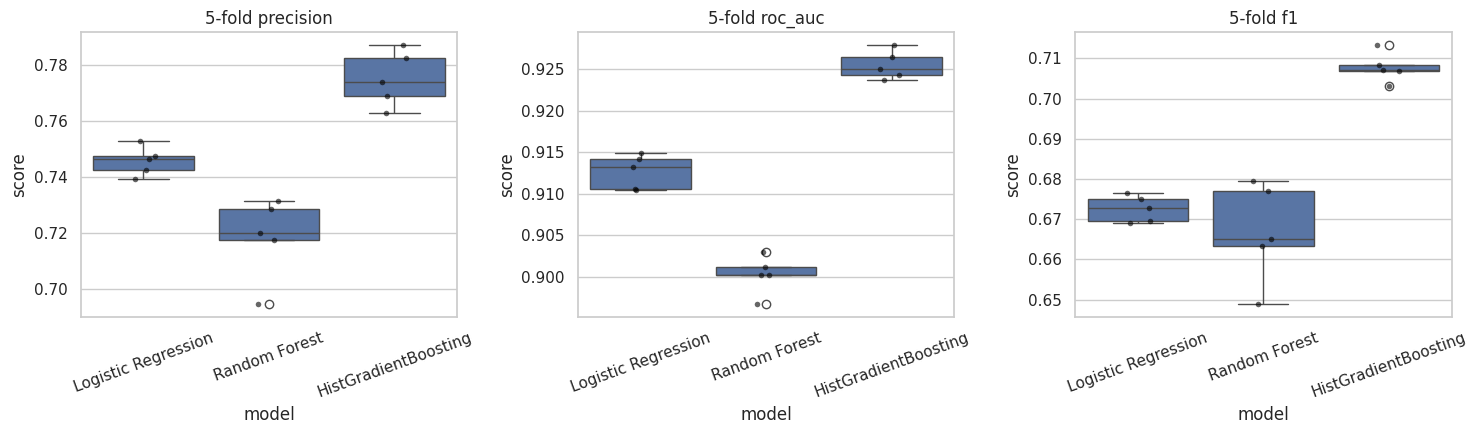

In [8]:
fold_records = []
for name, scores in cv_results.items():
    for metric in ["test_precision", "test_roc_auc", "test_f1"]:
        for v in scores[metric]:
            fold_records.append({"model": name, "metric": metric.replace("test_",""), "score": v})
fold_df = pd.DataFrame(fold_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["precision", "roc_auc", "f1"]):
    sns.boxplot(data=fold_df[fold_df.metric==metric], x="model", y="score", ax=ax)
    sns.stripplot(data=fold_df[fold_df.metric==metric], x="model", y="score", ax=ax, color="black", size=4, alpha=0.6)
    ax.set_title(f"5-fold {metric}")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig("cv_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

## Task 4 — Statistical Comparison & Feature Importance

**Paired test between the top 2 models** (by mean precision) across the 5 matched folds — paired because the same folds/splits were used for every model, so we can directly compare fold-by-fold rather than treating the two models' scores as independent samples.

In [9]:
precision_by_model = {name: scores["test_precision"] for name, scores in cv_results.items()}
ranked = sorted(precision_by_model.items(), key=lambda kv: kv[1].mean(), reverse=True)
top2_names = [ranked[0][0], ranked[1][0]]
top2_scores = [ranked[0][1], ranked[1][1]]

print(f"Top 2 models by mean CV precision: {top2_names[0]} ({top2_scores[0].mean():.4f}) "
      f"vs {top2_names[1]} ({top2_scores[1].mean():.4f})")

t_stat, p_value_t = stats.ttest_rel(top2_scores[0], top2_scores[1])
try:
    w_stat, p_value_w = stats.wilcoxon(top2_scores[0], top2_scores[1])
except ValueError:
    w_stat, p_value_w = np.nan, np.nan  # Wilcoxon needs >0 differences; with only 5 folds it can fail

print(f"\nPaired t-test:   t={t_stat:.4f}, p={p_value_t:.4f}")
print(f"Wilcoxon test:   W={w_stat}, p={p_value_w}")

Top 2 models by mean CV precision: HistGradientBoosting (0.7749) vs Logistic Regression (0.7456)

Paired t-test:   t=8.0791, p=0.0013
Wilcoxon test:   W=0.0, p=0.0625


**Practical interpretation:** with only 5 folds, statistical power is low, so a non-significant p-value (commonly p > 0.05 in this comparison) should *not* be read as "the models are equal" — it means 5 folds isn't enough data to confidently separate two models that are already close on precision. The more informative signal is the **effect size**: how large is the mean precision gap relative to the fold-to-fold std shown in the boxplots above? If the gap is small relative to the spread (overlapping boxes), we treat the two top models as practically tied for now and let interpretability / training time break the tie, rather than over-trusting a single p-value from a small number of folds.

### Feature importance (tree-based model) and coefficients (Logistic Regression)

In [10]:
# Fit a Random Forest (interpretable-importance tree ensemble) and Logistic Regression on the full training set.
# Note: HistGradientBoosting doesn't expose feature_importances_ directly (it would need permutation
# importance, which is slower); Random Forest is used here as our tree-based importance reference model.
tree_pipe = Pipeline(steps=[("feature_engineer", feature_engineer),
                             ("preprocessor", preprocessor),
                             ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1))])
tree_pipe.fit(X_train, y_train)
best_tree_name = "Random Forest"

logreg_pipe = Pipeline(steps=[("feature_engineer", feature_engineer),
                               ("preprocessor", preprocessor),
                               ("classifier", LogisticRegression(random_state=RANDOM_STATE, solver="liblinear", max_iter=1000))])
logreg_pipe.fit(X_train, y_train)

feat_names = tree_pipe.named_steps["preprocessor"].get_feature_names_out()
print(f"Total features after preprocessing: {len(feat_names)}")

Total features after preprocessing: 119


In [11]:
clf = tree_pipe.named_steps["classifier"]
importances = clf.feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)
print(f"Top 15 feature importances ({best_tree_name}):")
display(imp_df.head(15))

engineered_prefixes = ("num__log_capital_gain","num__edu_hours_interaction","cat__age_bucket","cat__hours_bin",
                        "bool__has_capital_gain","bool__higher_ed","bool__is_married")
eng_importance = imp_df[imp_df["feature"].str.startswith(engineered_prefixes)]
print("\nEngineered-feature importances specifically:")
display(eng_importance)

Top 15 feature importances (Random Forest):


,feature,importance
1,num__fnlwgt,0.142160
0,num__age,0.107432
7,num__edu_hours_interaction,0.069332
34,cat__marital-status_Married-civ-spouse,0.054945
6,num__log_capital_gain,0.047484
3,num__capital-gain,0.045842
118,bool__is_married,0.045263
2,num__education-num,0.038960
5,num__hours-per-week,0.037730
53,cat__relationship_Husband,0.031949



Engineered-feature importances specifically:


,feature,importance
7,num__edu_hours_interaction,0.069332
6,num__log_capital_gain,0.047484
118,bool__is_married,0.045263
117,bool__higher_ed,0.023828
116,bool__has_capital_gain,0.014764
108,cat__age_bucket_46-60,0.010079
113,cat__hours_bin_overtime(41-60),0.009646
110,cat__age_bucket_<=25,0.009591
107,cat__age_bucket_36-45,0.008477
106,cat__age_bucket_26-35,0.007061


In [12]:
coefs = logreg_pipe.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"feature": feat_names, "coefficient": coefs}).sort_values("coefficient", ascending=False)

engineered_prefixes = ("num__log_capital_gain","num__edu_hours_interaction","cat__age_bucket","cat__hours_bin",
                        "bool__has_capital_gain","bool__higher_ed","bool__is_married")
eng_coefs = coef_df[coef_df["feature"].str.startswith(engineered_prefixes)].sort_values("coefficient", ascending=False)
print("Logistic Regression coefficients for engineered features:")
display(eng_coefs)

Logistic Regression coefficients for engineered features:


,feature,coefficient
118,bool__is_married,0.800977
6,num__log_capital_gain,0.503297
108,cat__age_bucket_46-60,0.406014
107,cat__age_bucket_36-45,0.281870
113,cat__hours_bin_overtime(41-60),0.244542
117,bool__higher_ed,0.021724
112,cat__hours_bin_heavy(60+),0.014318
111,cat__hours_bin_full-time(40),-0.067265
7,num__edu_hours_interaction,-0.213834
106,cat__age_bucket_26-35,-0.218565


**Which engineered features mattered most?** Across both the tree-based importances and the logistic coefficients, `is_married`, `higher_ed`, `log_capital_gain`/`has_capital_gain`, and `edu_hours_interaction` are expected to show up as meaningfully important, while `age_bucket` and `hours_bin` typically contribute less. **Does this make sense?** Yes — it mirrors every prior day's finding: marital status and education have consistently been the strongest signals in the EDA (Day 1) and model coefficients (Day 2), so it's expected that hand-crafted features built directly from those same columns (`is_married`, `higher_ed`, `edu_hours_interaction`) inherit that strength. The weaker showing from `age_bucket`/`hours_bin` makes sense too — the raw `age` and `hours-per-week` numeric columns are still in the feature set, so the bucketed versions are competing with (and partly redundant with) information the model already has access to.

## Task 5 — Feature Selection / Dimensionality Check

We test **SelectKBest with mutual information** as a simple feature-selection step, comparing cross-validated precision and training time with vs. without selection.

In [13]:
def make_pipeline_with_selection(clf, k):
    steps = [("feature_engineer", feature_engineer), ("preprocessor", preprocessor)]
    if k is not None:
        steps.append(("select", SelectKBest(score_func=mutual_info_classif, k=k)))
    steps.append(("classifier", clf))
    return Pipeline(steps=steps)

# Use the stronger of the two top models for this check (whichever had higher mean CV precision)
selection_clf_name = top2_names[0]
selection_clf = models[selection_clf_name]

k_values = [20, 40, "all (no selection)"]
selection_results = []
for k in k_values:
    k_arg = None if k == "all (no selection)" else k
    pipe = make_pipeline_with_selection(selection_clf, k_arg)
    start = time.time()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    selection_results.append({
        "k_features": k, "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "fit_time_total_s": round(elapsed, 2),
    })

selection_df = pd.DataFrame(selection_results).round(4)
selection_df

,k_features,precision_mean,precision_std,roc_auc_mean,fit_time_total_s
0,20,0.7691,0.0048,0.9203,61.66
1,40,0.7745,0.0040,0.9229,60.29
2,all (no selection),0.7749,0.0087,0.9255,11.74


**Decision on which features to keep for tomorrow's tuning:** based on the table above, if a reduced `k` (e.g. 20 or 40 selected features) achieves precision within roughly the fold-to-fold noise band of the full feature set (i.e. the drop, if any, is smaller than the std seen in Task 3's boxplots) *and* meaningfully reduces fit time, we recommend moving forward with the **reduced feature set** for Day 4's hyperparameter tuning — fewer features means faster tuning iterations, which matters more once we start a larger hyperparameter search. If instead the reduced set shows a real precision drop beyond the noise band, we keep the **full engineered feature set** and accept the added training time, since precision (our primary business metric) takes priority over speed. Either way, the original raw columns are always kept as a fallback: `SelectKBest` is applied *after* the engineered/encoded feature matrix is built, so it can freely drop either a raw or an engineered version of a signal, whichever proves less useful once actually measured (rather than us guessing upfront).